<a href="https://colab.research.google.com/github/VenkatNarayananManjunath/AI-Experiments/blob/main/PragyanAIproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Load dataset
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

# Target variable
y = np.log1p(df["median_house_value"])

# ================= BASELINE MODELS =================
print("\n=========== BASELINE MODELS ===========")

baseline_features = ["housing_median_age","total_rooms","total_bedrooms",
                     "population","households","median_income"]

X = df[baseline_features]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4)
}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)

    print(f"\n{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))
    print("MAE:", mean_absolute_error(y_test,pred))
    print("R2:", r2_score(y_test,pred))


# ================= FEATURE ENGINEERING =================
print("\n=========== FEATURE ENGINEERING MODELS ===========")

df["rooms_per_household"] = df["total_rooms"]/df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"]/df["total_rooms"]
df["population_per_household"] = df["population"]/df["households"]

feature_cols = baseline_features + [
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household"
]

X = df[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)

    print(f"\n{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))
    print("MAE:", mean_absolute_error(y_test,pred))
    print("R2:", r2_score(y_test,pred))


# ================= HYPERPARAMETER TUNING =================
print("\n=========== HYPERPARAMETER TUNED XGBOOST ===========")

param_grid = {
    "n_estimators":[300,500],
    "learning_rate":[0.01,0.03,0.05],
    "max_depth":[3,4,5],
    "subsample":[0.8,1],
    "colsample_bytree":[0.8,1]
}

xgb = XGBRegressor(random_state=42)

grid = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_s, y_train)

best_model = grid.best_estimator_

pred = best_model.predict(X_test_s)

print("\nBest Parameters:", grid.best_params_)
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))
print("MAE:", mean_absolute_error(y_test,pred))
print("R2:", r2_score(y_test,pred))


=========== BASELINE MODELS ===========

Linear Regression
RMSE: 0.3865816621586429
MAE: 0.29975358831332577
R2: 0.5489194338465821

Ridge
RMSE: 0.38658185625360053
MAE: 0.2997590803737071
R2: 0.5489189808893216

Lasso
RMSE: 0.3867316430529979
MAE: 0.3001210300322667
R2: 0.5485693572805426

XGBoost
RMSE: 0.3327621801433383
MAE: 0.25087492705337977
R2: 0.6657745315002985

=========== FEATURE ENGINEERING MODELS ===========

Linear Regression
RMSE: 0.38073225701354463
MAE: 0.2938621658334182
R2: 0.5624668476972685

Ridge
RMSE: 0.3807325431515401
MAE: 0.2938687351350449
R2: 0.5624661900440024

Lasso
RMSE: 0.38078285672666784
MAE: 0.29417935234584097
R2: 0.5623505427468365

XGBoost
RMSE: 0.3235304586751336
MAE: 0.24108991204546354
R2: 0.6840619264640284

=========== HYPERPARAMETER TUNED XGBOOST ===========

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
RMSE: 0.3195012349801273
MAE: 0.23769788392528304
R2: 0.69188226

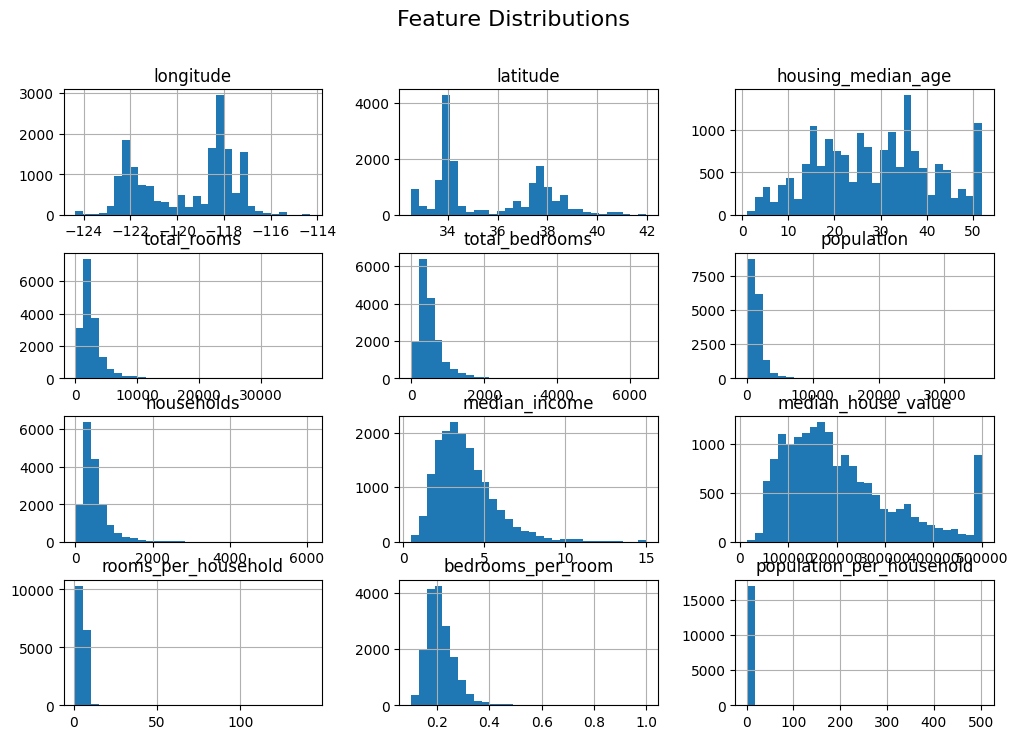

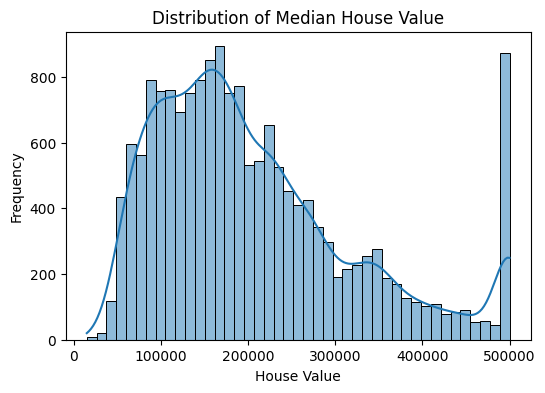

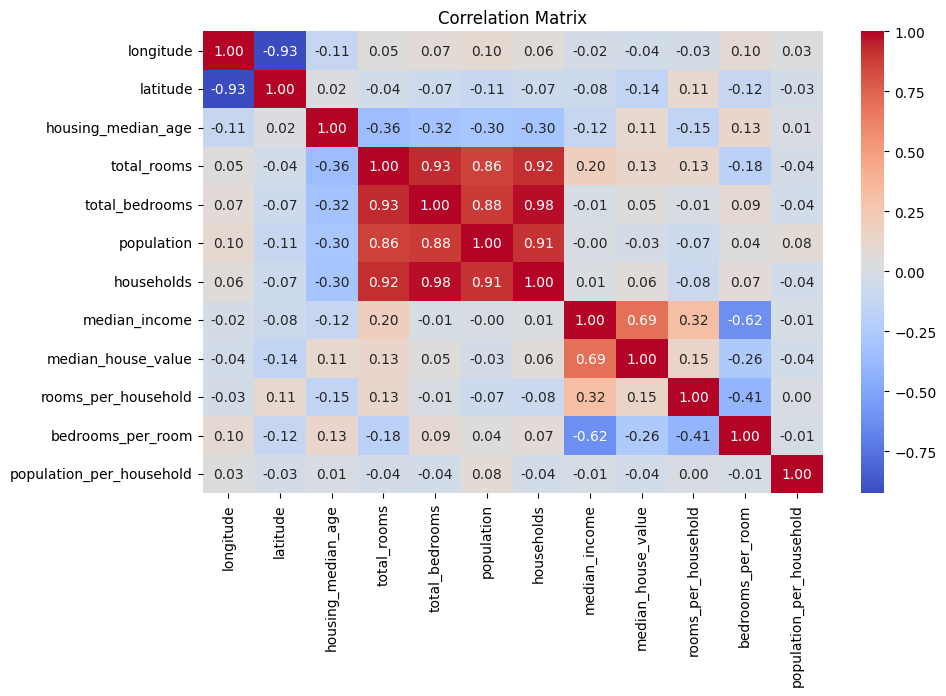

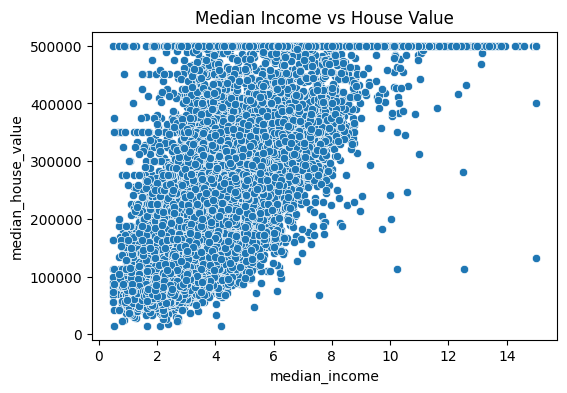

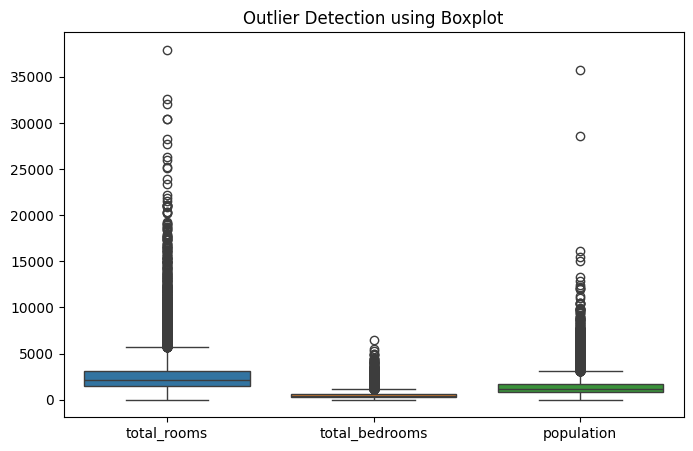

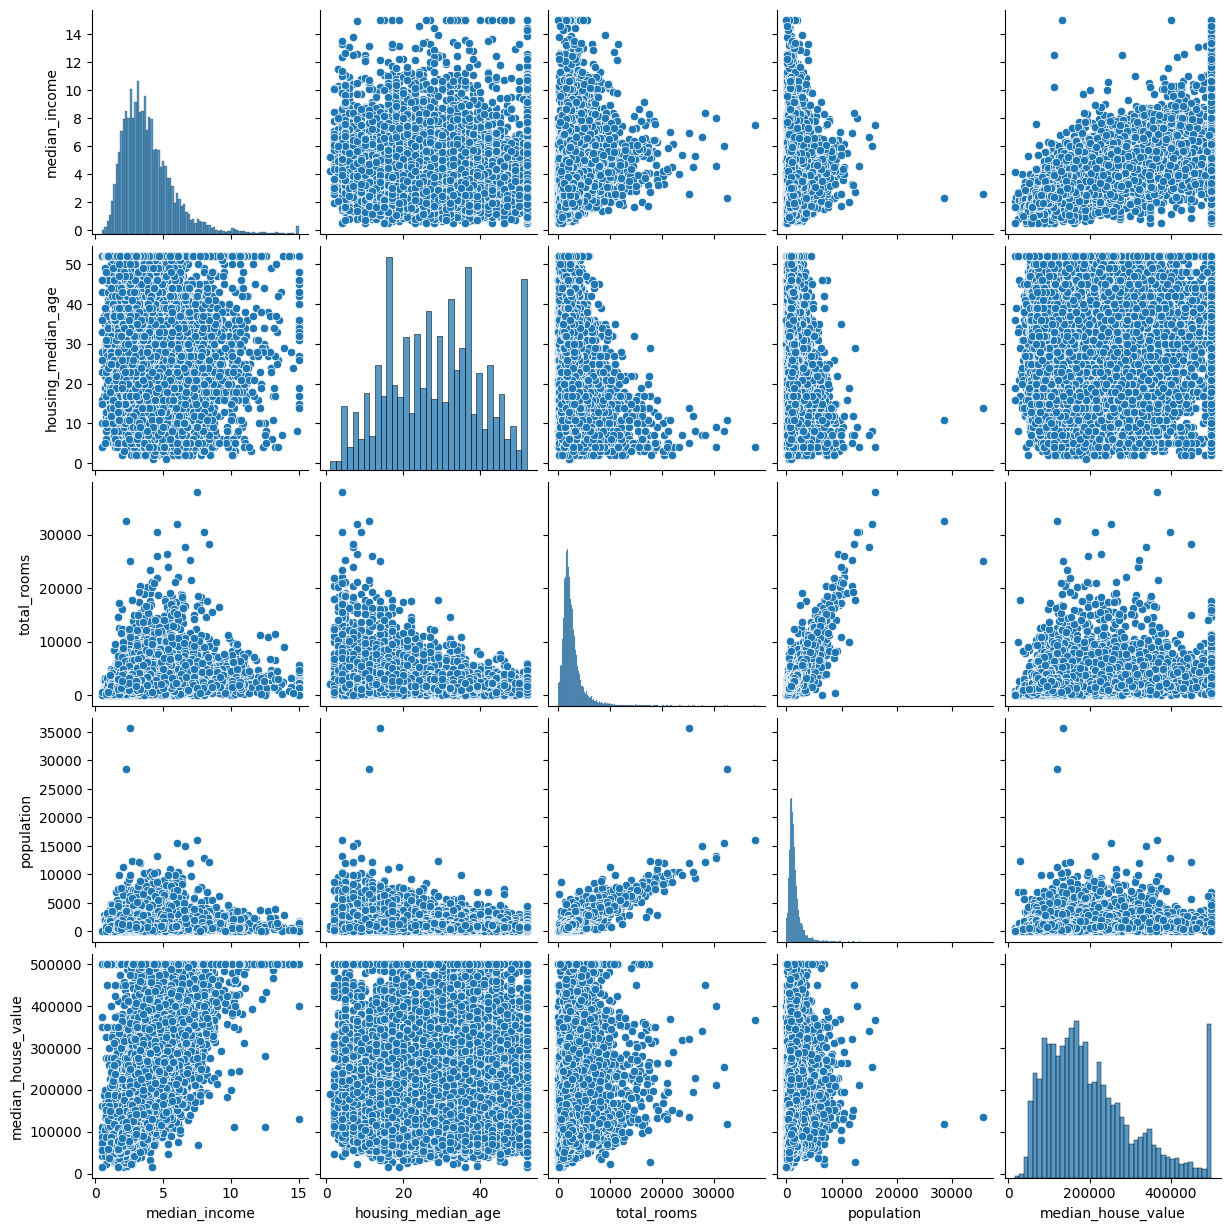

<Figure size 800x600 with 0 Axes>

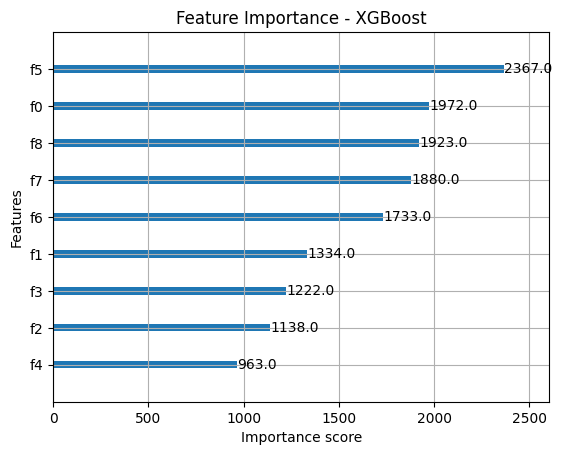

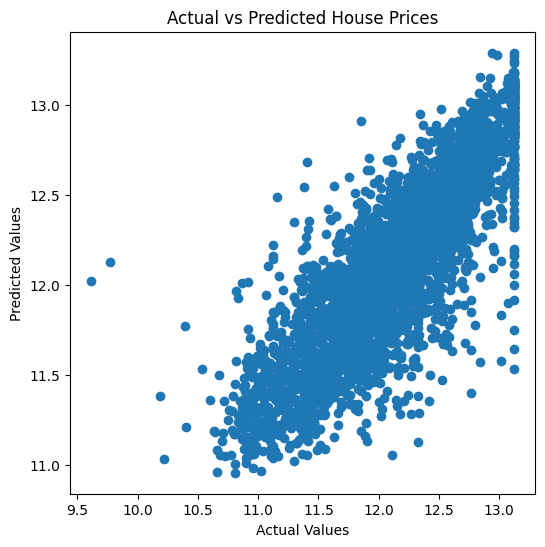

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import plot_importance

# ================= HISTOGRAMS =================
df.hist(bins=30, figsize=(12,8))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# ================= TARGET DISTRIBUTION =================
plt.figure(figsize=(6,4))
sns.histplot(df["median_house_value"], kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("House Value")
plt.ylabel("Frequency")
plt.show()

# ================= CORRELATION HEATMAP =================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# ================= SCATTER PLOT =================
plt.figure(figsize=(6,4))
sns.scatterplot(x="median_income", y="median_house_value", data=df)
plt.title("Median Income vs House Value")
plt.show()

# ================= BOXPLOT =================
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["total_rooms","total_bedrooms","population"]])
plt.title("Outlier Detection using Boxplot")
plt.show()

# ================= PAIRPLOT =================
sns.pairplot(df[["median_income","housing_median_age","total_rooms","population","median_house_value"]])
plt.show()

# ================= FEATURE IMPORTANCE =================
plt.figure(figsize=(8,6))
plot_importance(best_model)
plt.title("Feature Importance - XGBoost")
plt.show()

# ================= ACTUAL VS PREDICTED =================
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")
plt.show()

Software Requirements
Component	Requirement:
Programming Language	Python 3.8+

Operating System	Windows

Python Libraries Required


NumPy	:Mathematical operations and arrays

Pandas	:Data preprocessing and manipulation

Matplotlib	:Data visualization

Seaborn	:Advanced statistical plots

Scikit-learn	:ML models, preprocessing, evaluation

XGBoost	:High-performance regression model